# United Airlines — 2018 On-Time Performance
## Exploratory Data Analysis

**Project:** United 2018 On-Time Performance — delay/cancellation risk & delay-cause prediction
**Phase:** Analyze (EDA) — PACE framework
**Data:** BTS On-Time Performance data, UA mainline, all domestic flights scheduled in 2018

This notebook consolidates the EDA outputs (charts + summary statistics) generated for this
project into a single walkthrough: hub effects, seasonality, day/hour timing patterns, delay
causes, and the distance–delay relationship.

**Contents**
1. [Methodology](#methodology)
2. [System-Wide KPIs](#kpis)
3. [Delay Rate by Hub](#hub)
4. [Monthly Seasonal Trend](#monthly)
5. [Delay Timing — Day of Week × Hour](#heatmap)
6. [Delay-Cause Composition by Hub](#cause)
7. [Cancellation Rate by Month](#cancel)
8. [Distance vs. Delay](#distance)
9. [Key Takeaways](#takeaways)


<a id="methodology"></a>
## 1. Methodology

| Term | Definition |
|---|---|
| **Delayed** | `DEP_DELAY >= 15 minutes` (FAA/DOT standard threshold) |
| **Hub** | Origin airport, limited to UA's 7 largest 2018 stations by volume: ORD, DEN, IAH, SFO, EWR, LAX, IAD |
| **Confidence interval** | Wilson score interval, 95% (more reliable than the normal approximation for proportions near 0 or with small *n*) |

All rates below are departure-side (`ORIGIN` airport), computed across the full 2018 UA mainline schedule.

<a id="kpis"></a>
## 2. System-Wide KPIs

| Metric | Value | 95% CI |
|---|---|---|
| Total flights | 621,565 | — |
| Delay rate (15+ min) | 17.09% | [17.00%, 17.19%] |
| Cancellation rate | 0.79% | [0.77%, 0.81%] |
| Avg. delay, *when delayed* | 74.7 min | — |


<a id="hub"></a>
## 3. Delay Rate by Hub

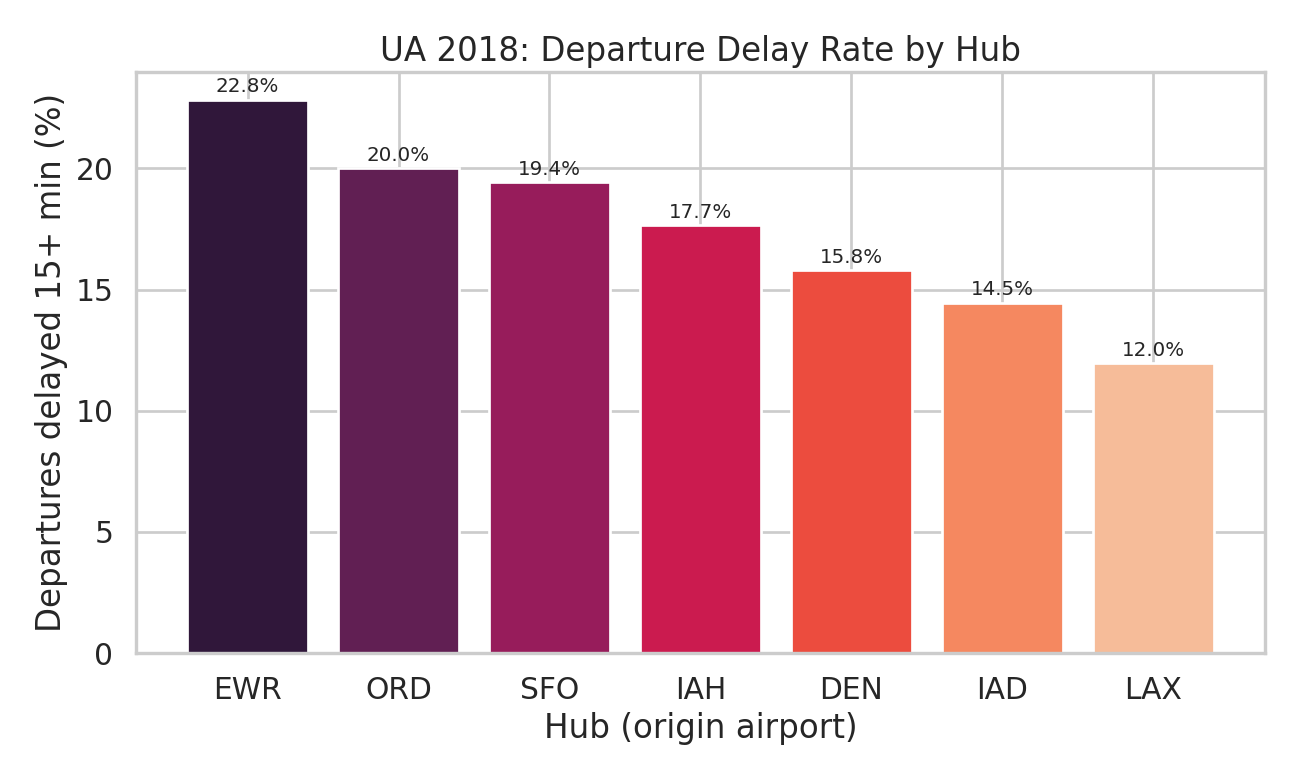

| Hub | Flights | Delay Rate | 95% CI | Cancellation Rate | Avg Dep Delay (min, all flights) |
|---|---:|---:|---|---:|---:|
| EWR | 58,321 | 22.84% | [22.50%, 23.18%] | 1.78% | 15.19 |
| ORD | 77,418 | 20.02% | [19.74%, 20.30%] | 0.94% | 12.32 |
| SFO | 60,485 | 19.44% | [19.13%, 19.76%] | 0.36% | 10.49 |
| IAH | 61,376 | 17.66% | [17.36%, 17.97%] | 0.54% | 9.54 |
| DEN | 63,204 | 15.80% | [15.52%, 16.09%] | 0.32% | 8.53 |
| IAD | 25,624 | 14.46% | [14.03%, 14.90%] | 0.50% | 9.22 |
| LAX | 28,774 | 11.96% | [11.59%, 12.34%] | 0.34% | 4.74 |

**Statistical test — hub × delayed/not (chi-square test of independence)**

- χ² = 2318.8, dof = 6, p < 0.001
- Cramér's V = 0.0786 (small–moderate effect by Cohen's convention)
- **Interpretation:** hub is a statistically real driver of delay (p < 0.001), but the effect
  size is modest — hub alone explains only a small share of overall delay variance. Useful
  predictor, not a dominant one.

<a id="monthly"></a>
## 4. Monthly Seasonal Trend

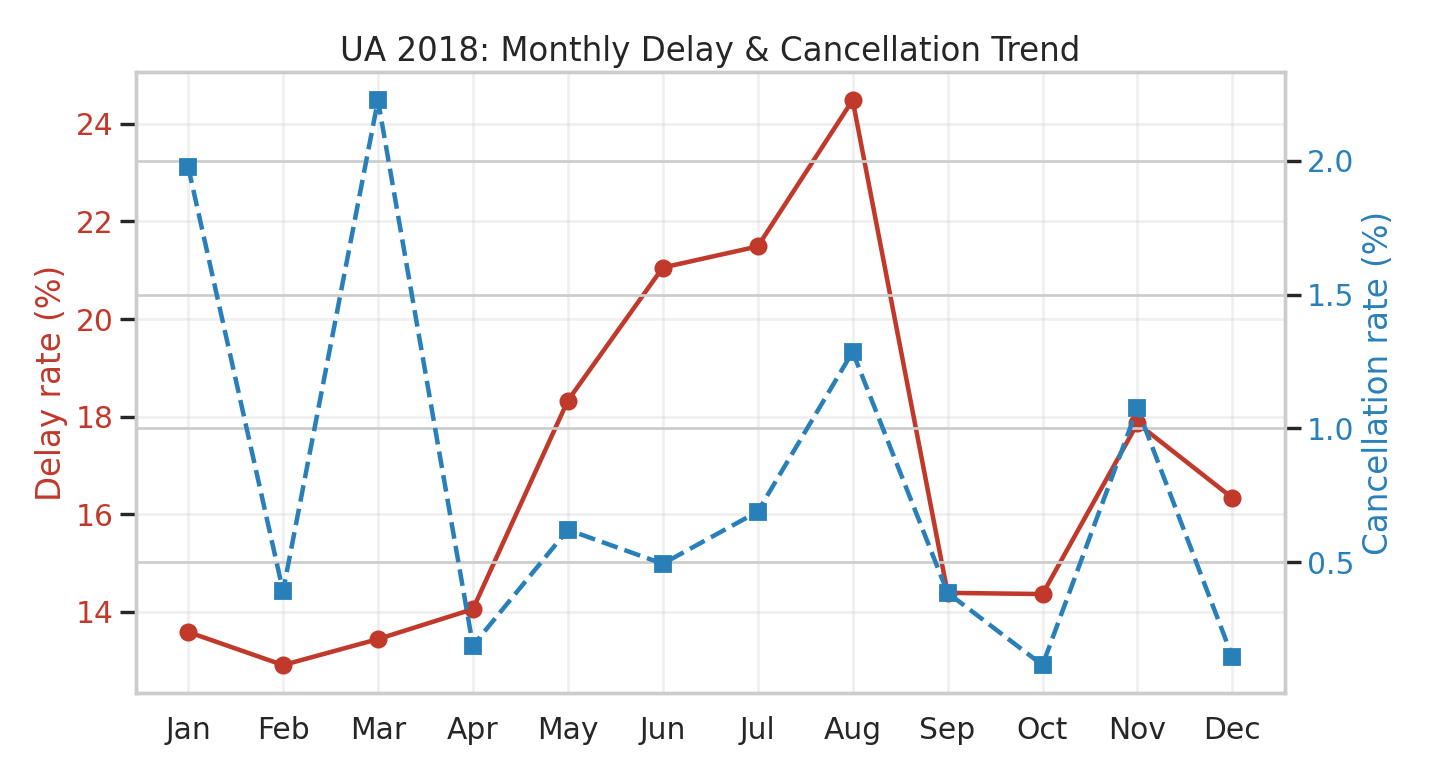

| Month | Flights | Delay Rate | Cancellation Rate |
|---|---:|---:|---:|
| Jan | 45,384 | 13.58% | 1.98% |
| Feb | 41,650 | 12.91% | 0.39% |
| Mar | 49,800 | 13.44% | 2.23% |
| Apr | 49,937 | 14.05% | 0.19% |
| May | 52,816 | 18.33% | 0.62% |
| Jun | 55,056 | 21.05% | 0.49% |
| Jul | 57,209 | 21.49% | 0.69% |
| Aug | 57,921 | 24.49% | 1.29% |
| Sep | 52,905 | 14.39% | 0.39% |
| Oct | 55,565 | 14.36% | 0.12% |
| Nov | 51,792 | 17.86% | 1.08% |
| Dec | 51,530 | 16.33% | 0.15% |

Delay rate climbs sharply from spring into a summer peak (Aug: 24.49%), then drops back down
in fall. Cancellations spike separately in Jan/Mar (winter weather) and Aug/Nov, decoupled
from the delay-rate seasonality — i.e. the driver of cancellations isn't simply "the same
months that run late.

<a id="heatmap"></a>
## 5. Delay Timing — Day of Week × Hour

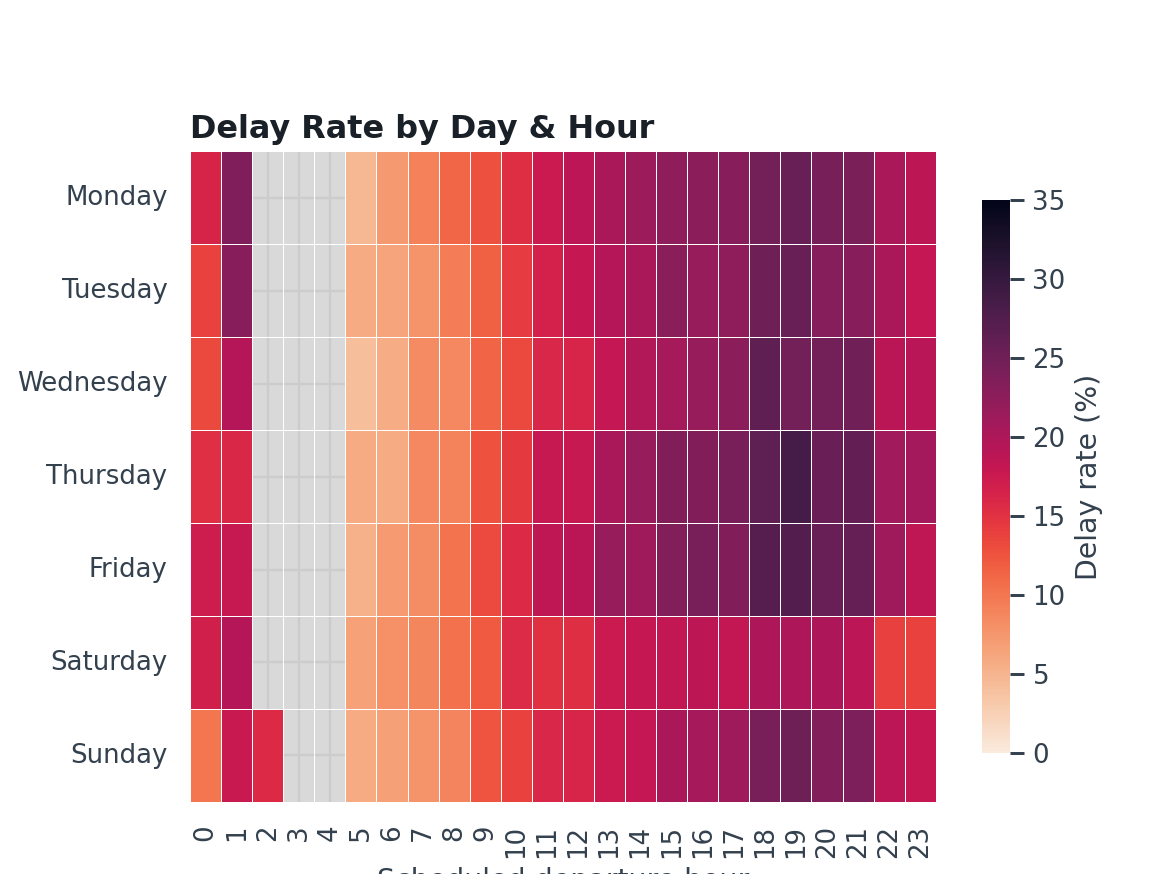

Delay rate climbs steadily through the day and peaks in the evening (roughly hour 18–21)
across all seven days, consistent with delay propagation compounding as the day goes on.

**Data quality note:** cells with *n* < 30 flights (mostly the 2:00–4:59 AM red-eye slots,
*n* as low as 1–6 for some day/hour pairs) are suppressed (shown grey) rather than plotted,
since a rate computed on a handful of flights is not a reliable estimate and would visually
dominate the color scale — one such cell showed 100% on *n* = 1–3 before masking.

<a id="cause"></a>
## 6. Delay-Cause Composition by Hub

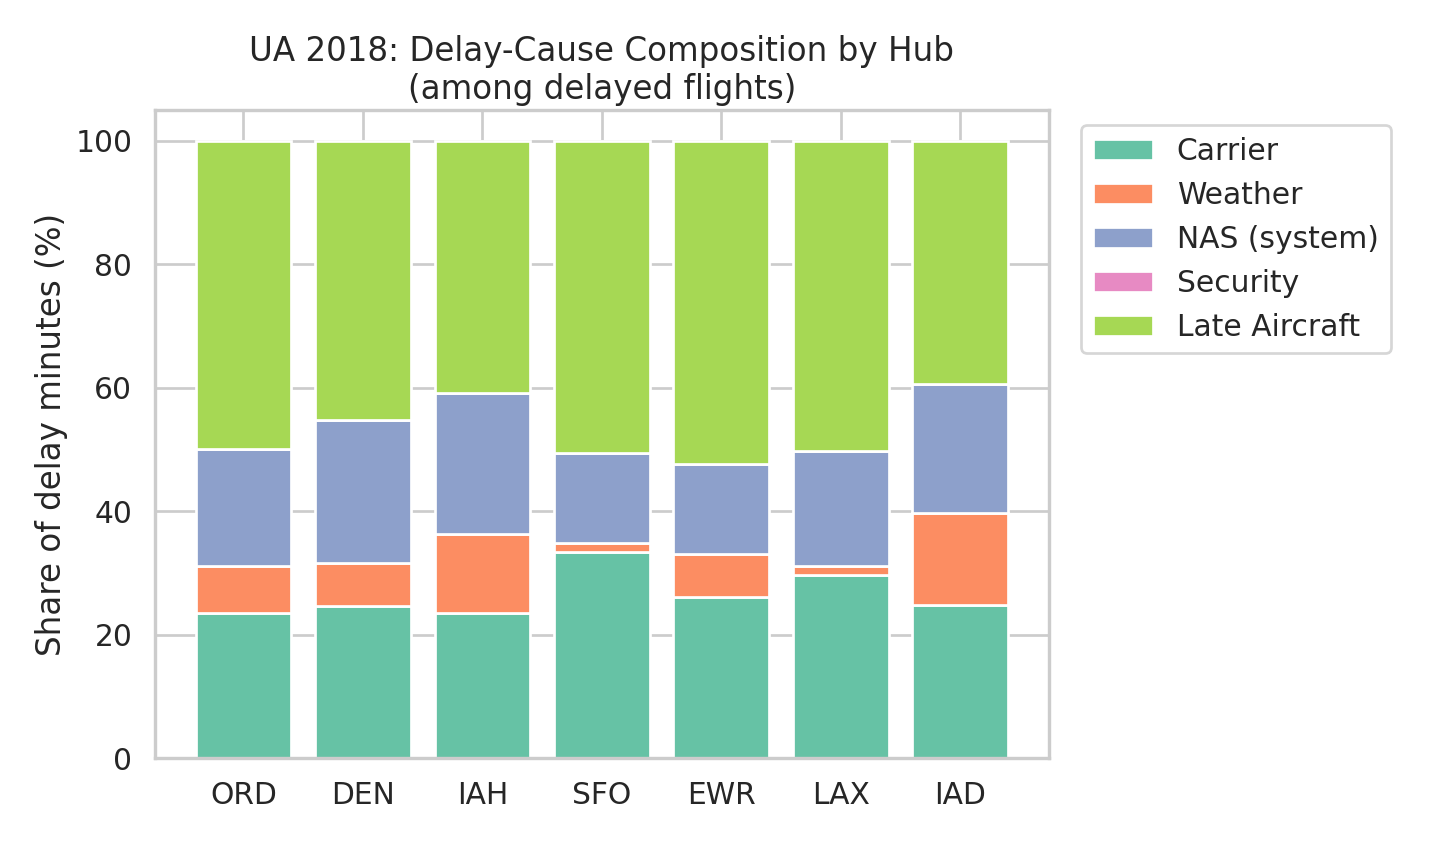

Share of delay-minutes by cause, among already-delayed flights, per hub. **Late Aircraft**
and **Carrier** delay are the largest contributors at most hubs, with **NAS (system)** delay
making up a meaningful secondary share; **Security** delay is negligible everywhere. This
composition — not just the raw delay rate — is what Model B (delay-cause prediction) targets.

<a id="cancel"></a>
## 7. Cancellation Rate by Month

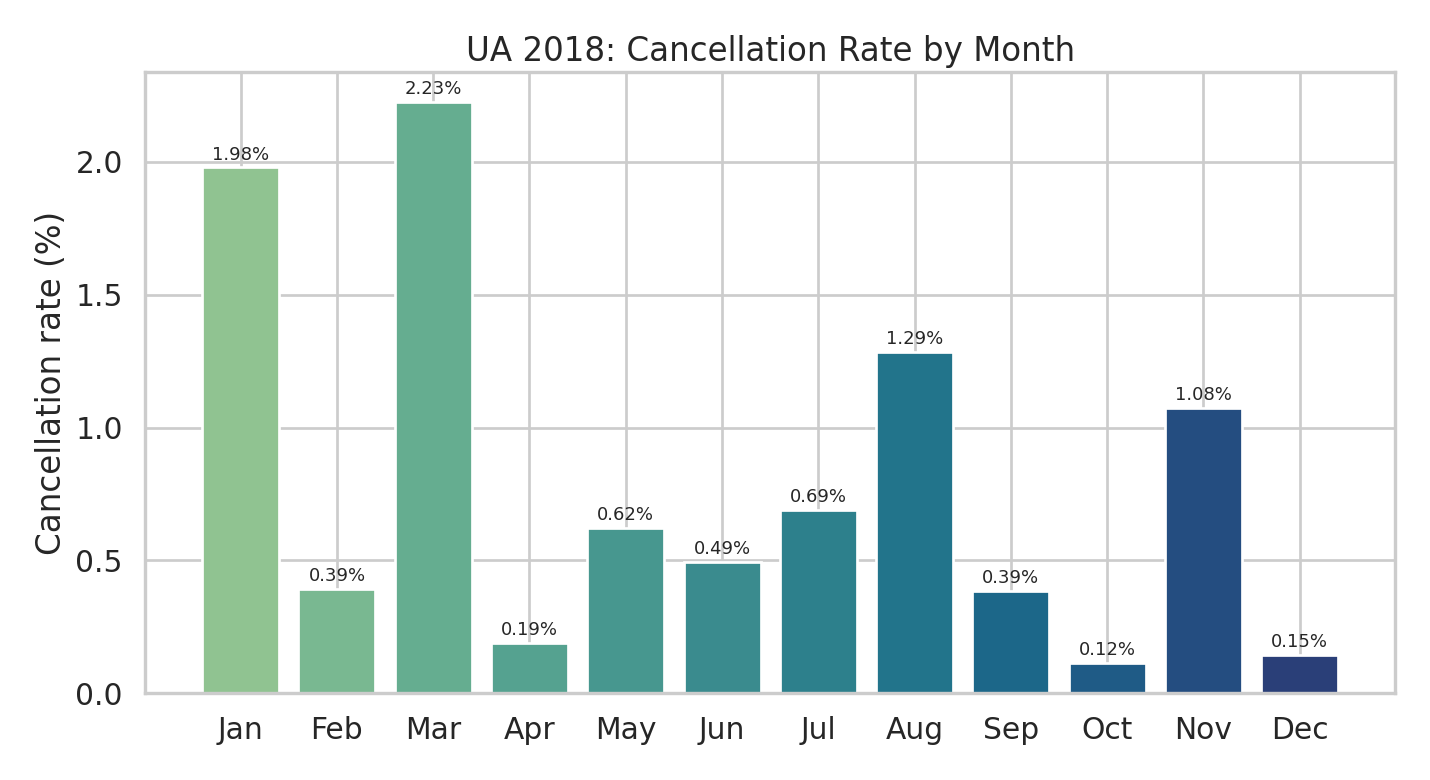

Cancellations are dominated by two winter-weather months, **Mar (2.23%)** and **Jan (1.98%)**,
with a secondary **Aug (1.29%)** peak — notably the same month that also has the worst delay
rate, unlike Jan/Mar which cancel heavily without ranking among the worst delay months (see
§4). This split (weather-driven winter cancellations vs. congestion-driven summer delay)
supports treating cancellation and delay as related but distinct target variables, as planned
for Model A.

<a id="distance"></a>
## 8. Distance vs. Delay

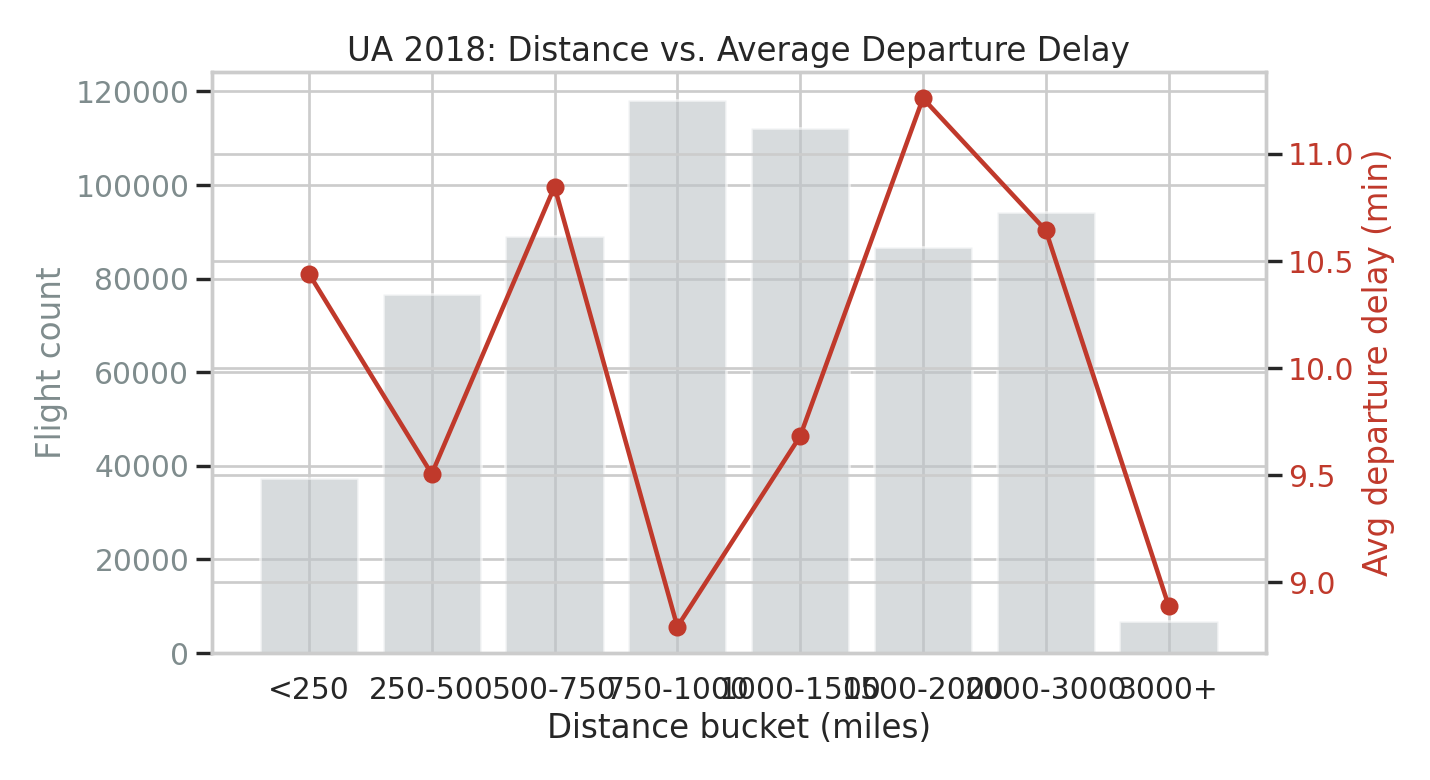

| Distance Bucket | Flights | Avg Dep Delay (min) | Delay Rate |
|---|---:|---:|---:|
| <250 mi | 37,339 | 10.44 | 17.18% |
| 250–500 mi | 76,799 | 9.51 | 16.92% |
| 500–750 mi | 89,034 | 10.85 | 17.98% |
| 750–1000 mi | 118,257 | 8.79 | 15.84% |
| 1000–1500 mi | 112,173 | 9.68 | 16.68% |
| 1500–2000 mi | 86,871 | 11.26 | 18.30% |
| 2000–3000 mi | 94,302 | 10.64 | 17.50% |
| 3000+ mi | 6,790 | 8.89 | 14.71% |

**Correlation:** system-wide Pearson r = 0.0075 (p = 3.48e-09) — statistically significant
only because *n* is very large (>600k); practically the relationship is negligible (|r| < 0.01).

**Per-hub check (Simpson's paradox test):**

| Hub | r | p | n |
|---|---:|---:|---:|
| ORD | 0.0064 | 0.077 | 77,418 |
| DEN | 0.0212 | 9.86e-08 | 63,204 |
| IAH | 0.0355 | 1.33e-18 | 61,376 |
| SFO | 0.0419 | 6.86e-25 | 60,485 |
| EWR | -0.0149 | 3.29e-04 | 58,321 |
| LAX | 0.0285 | 1.35e-06 | 28,774 |
| IAD | -0.0133 | 0.0338 | 25,624 |

No hub shows a meaningfully different or opposite-signed relationship large enough to change
the system-wide conclusion: **flight distance is not a useful predictor of delay** on its own.

<a id="takeaways"></a>
## 9. Key Takeaways for Feature Engineering

- **Hub matters, but modestly** (Cramér's V = 0.079) — worth including as a categorical
  feature, not a strong standalone predictor.
- **Strong seasonality** (delay) — summer (Jun–Aug) is the high-risk window; keep month/season
  as a feature.
- **Cancellation seasonality is different from delay seasonality** — winter weather (Jan, Mar)
  drives cancellations more than summer congestion does; the two targets need separate feature
  emphasis, not a single "bad month" flag.
- **Time-of-day is a strong signal** — delay rate rises through the day and peaks in the
  evening across all seven days; scheduled departure hour should be a core feature.
- **Distance is not predictive** (|r| < 0.01 system-wide and per-hub) — safe to deprioritize
  or drop as a feature for the delay-rate model.
- **Delay cause composition varies by hub** — supports keeping hub as a feature for Model B
  (delay-cause prediction), even though its effect on Model A (delay/no-delay) is modest.
